Car vs truc CNN model 90%

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd

from keras import Sequential, layers, callbacks, losses, utils, optimizers, applications, datasets, Input
from keras.preprocessing import image_dataset_from_directory

2026-01-01 18:01:36.276488: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/paul/Desktop/projects/modelz/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1767312098.906742   88049 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2100 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:2b:00.0, compute capability: 7.5


Preprocess data and create the training and validation split 80% / 20%.

In [3]:
#ds_train, ds_valid = datasets.mnist.load_data()

          
size = 299

batch_size = 16

seed = 123

#buffer = 1000
data_dir = "../data/tests/car_vs_truck"

input_shape = [size,size,3]

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=seed,
    subset="training",
    image_size=(size,size),
    batch_size=batch_size,
    shuffle=True
    )

ds_valid= image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    seed=seed,
    subset="validation",
    image_size=(size,size),
    batch_size=batch_size,
    shuffle=True
    )

#class_names = ds_train.class_names # type: ignore
#num_classes = len(ds_train)
#print(class_names)

Found 10168 files belonging to 2 classes.
Using 8135 files for training.
Found 10168 files belonging to 2 classes.
Using 2033 files for validation.


In [4]:
%%capture
for image_batch, labels_batch in ds_train:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

In [5]:
#memory errors
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_valid = ds_valid.cache().prefetch(buffer_size=AUTOTUNE)



In [ ]:
padding = "same"

body = applications.Xception(weights="imagenet", include_top=False)
body.trainable = False
model_layers = [
    
    #Preprocessing
    layers.Rescaling(1./255),
    
    layers.RandomFlip(mode="vertical"),
    layers.RandomPerspective(0.2),
  
    # Body
    body,
    
    # Classifier head   
    layers.Flatten(),
    layers.Dense(1024,activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(512,activation="relu"),
    #layers.Dense(128,activation="relu"),
    
    #layers.Dense(64,activation="relu"),
    layers.Dense(1, activation="sigmoid")
]


In [7]:

model = Sequential(layers=model_layers)

early_stopping = callbacks.EarlyStopping(patience=5,
                                      min_delta=0.001,restore_best_weights=True)

optimizer = optimizers.Adam(learning_rate=0.002)
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
    
)
model.name = "car_vs_truck"

Train the model

In [8]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    callbacks=[early_stopping],
    epochs=50,
)

Epoch 1/50


I0000 00:00:1767312104.608501   89145 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x2e0a8e20
2026-01-01 18:01:44.661295: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-01 18:01:45.250899: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
2026-01-01 18:01:45.539534: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.55GiB with freed_by_count=0. The caller indicates that this is not a fai

508/509 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - binary_accuracy: 0.7287 - loss: 0.5331

2026-01-01 18:03:56.591917: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-01 18:03:56.772631: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.19GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-01 18:03:56.937167: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.94GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


509/509 ━━━━━━━━━━━━━━━━━━━━ 168s 318ms/step - binary_accuracy: 0.7510 - loss: 0.5134 - val_binary_accuracy: 0.8465 - val_loss: 0.3669
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 147s 289ms/step - binary_accuracy: 0.7808 - loss: 0.4718 - val_binary_accuracy: 0.8569 - val_loss: 0.3431
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 151s 296ms/step - binary_accuracy: 0.7807 - loss: 0.4658 - val_binary_accuracy: 0.8642 - val_loss: 0.3256
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 145s 285ms/step - binary_accuracy: 0.7871 - loss: 0.4536 - val_binary_accuracy: 0.8682 - val_loss: 0.3294
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - binary_accuracy: 0.7898 - loss: 0.4402 - val_binary_accuracy: 0.8770 - val_loss: 0.3118
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - binary_accuracy: 0.8045 - loss: 0.4323 - val_binary_accuracy: 0.8770 - val_loss: 0.3105
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - binary_accuracy: 0.8033 - loss: 0.4243 - val_binary_accuracy: 0.8628 - val_lo

<Axes: >

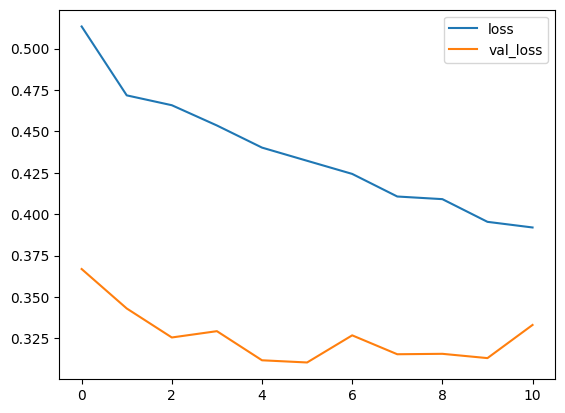

In [9]:

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()

In [10]:
model.summary()

Model: "car_vs_truck"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_perspective              │ (None, 299, 299, 3)    │             0 │
│ (RandomPerspective)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 1000)           │    22,910,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,025,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,349,461 (108.14 MB)

 Trainable params: 1,812,993 (6.92 MB)

 Non-trainable params: 22,910,480 (87.40 MB)

 Optimizer params: 3,625,988 (13.83 MB)